In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

DATA_FOLDER = r"C:\Users\sarin\Downloads\nifty50_project\data"
OUTPUT_FOLDER = r"C:\Users\sarin\Downloads\nifty50_project\outputs"
os.makedirs(OUTPUT_FOLDER, exist_ok=True)

print("Libraries loaded ✅")

Libraries loaded ✅


In [2]:
def load_all_stocks(folder):
    all_dfs = []
    files = [f for f in os.listdir(folder) if f.endswith(".csv")]
    print(f"Found {len(files)} CSV files")
    
    for file in files:
        ticker = file.replace(".csv", "")
        df = pd.read_csv(os.path.join(folder, file))
        df.columns = df.columns.str.strip().str.lower()
        df['ticker'] = ticker
        all_dfs.append(df)
    
    combined = pd.concat(all_dfs, ignore_index=True)
    return combined

df = load_all_stocks(DATA_FOLDER)
print(f"Total rows: {df.shape[0]}")
print(f"Total columns: {df.shape[1]}")
print("\nColumns:", df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Found 52 CSV files
Total rows: 470434
Total columns: 19

Columns: ['date', 'symbol', 'series', 'prev close', 'open', 'high', 'low', 'last', 'close', 'vwap', 'volume', 'turnover', 'trades', 'deliverable volume', '%deliverble', 'ticker', 'company name', 'industry', 'isin code']

First 5 rows:


,date,symbol,series,prev close,open,high,low,last,close,vwap,volume,turnover,trades,deliverable volume,%deliverble,ticker,company name,industry,isin code
0,2007-11-27,MUNDRAPORT,EQ,440.0,770.0,1050.0,770.0,959.0,962.9,984.72,27294366,2687719053785000.0,NaN,9859619,0.3612,ADANIPORTS,NaN,NaN,NaN
1,2007-11-28,MUNDRAPORT,EQ,962.9,984.0,990.0,874.0,885.0,893.9,941.38,4581338,431276530165000.0,NaN,1453278,0.3172,ADANIPORTS,NaN,NaN,NaN
2,2007-11-29,MUNDRAPORT,EQ,893.9,909.0,914.75,841.0,887.0,884.2,888.09,5124121,455065846265000.0,NaN,1069678,0.2088,ADANIPORTS,NaN,NaN,NaN
3,2007-11-30,MUNDRAPORT,EQ,884.2,890.0,958.0,890.0,929.0,921.55,929.17,4609762,428325662830000.0,NaN,1260913,0.2735,ADANIPORTS,NaN,NaN,NaN
4,2007-12-03,MUNDRAPORT,EQ,921.55,939.75,995.0,922.0,980.0,969.3,965.65,2977470,287519974300000.0,NaN,816123,0.2741,ADANIPORTS,NaN,NaN,NaN


In [3]:
# Fix date column
df['date'] = pd.to_datetime(df['date'])

# Drop duplicates
df = df.drop_duplicates(subset=['ticker', 'date'])

# Sort
df = df.sort_values(['ticker', 'date']).reset_index(drop=True)

# Check missing values in key columns
print("Missing values in key columns:")
print(df[['date','ticker','open','high','low','close','volume']].isnull().sum())

print(f"\nDate range: {df['date'].min()} → {df['date'].max()}")
print(f"Unique tickers: {df['ticker'].nunique()}")
print(f"\nTickers: {sorted(df['ticker'].unique().tolist())}")

Missing values in key columns:
date      1
ticker    0
open      1
high      1
low       1
close     1
volume    1
dtype: int64

Date range: 2000-01-03 00:00:00 → 2021-04-30 00:00:00
Unique tickers: 51

Tickers: ['ADANIPORTS', 'ASIANPAINT', 'AXISBANK', 'BAJAJ-AUTO', 'BAJAJFINSV', 'BAJFINANCE', 'BHARTIARTL', 'BPCL', 'BRITANNIA', 'CIPLA', 'COALINDIA', 'DRREDDY', 'EICHERMOT', 'GAIL', 'GRASIM', 'HCLTECH', 'HDFC', 'HDFCBANK', 'HEROMOTOCO', 'HINDALCO', 'HINDUNILVR', 'ICICIBANK', 'INDUSINDBK', 'INFY', 'IOC', 'ITC', 'JSWSTEEL', 'KOTAKBANK', 'LT', 'MARUTI', 'MM', 'NESTLEIND', 'NIFTY50_all', 'NTPC', 'ONGC', 'POWERGRID', 'RELIANCE', 'SBIN', 'SHREECEM', 'SUNPHARMA', 'TATAMOTORS', 'TATASTEEL', 'TCS', 'TECHM', 'TITAN', 'ULTRACEMCO', 'UPL', 'VEDL', 'WIPRO', 'ZEEL', 'stock_metadata']


In [4]:
# Check what industry info we have
industry_info = df.groupby('ticker')['industry'].first().reset_index()
print(industry_info.to_string())

            ticker  industry
0       ADANIPORTS       NaN
1       ASIANPAINT       NaN
2         AXISBANK       NaN
3       BAJAJ-AUTO       NaN
4       BAJAJFINSV       NaN
5       BAJFINANCE       NaN
6       BHARTIARTL       NaN
7             BPCL       NaN
8        BRITANNIA       NaN
9            CIPLA       NaN
10       COALINDIA       NaN
11         DRREDDY       NaN
12       EICHERMOT       NaN
13            GAIL       NaN
14          GRASIM       NaN
15         HCLTECH       NaN
16            HDFC       NaN
17        HDFCBANK       NaN
18      HEROMOTOCO       NaN
19        HINDALCO       NaN
20      HINDUNILVR       NaN
21       ICICIBANK       NaN
22      INDUSINDBK       NaN
23            INFY       NaN
24             IOC       NaN
25             ITC       NaN
26        JSWSTEEL       NaN
27       KOTAKBANK       NaN
28              LT       NaN
29          MARUTI       NaN
30              MM       NaN
31       NESTLEIND       NaN
32     NIFTY50_all       NaN
33            

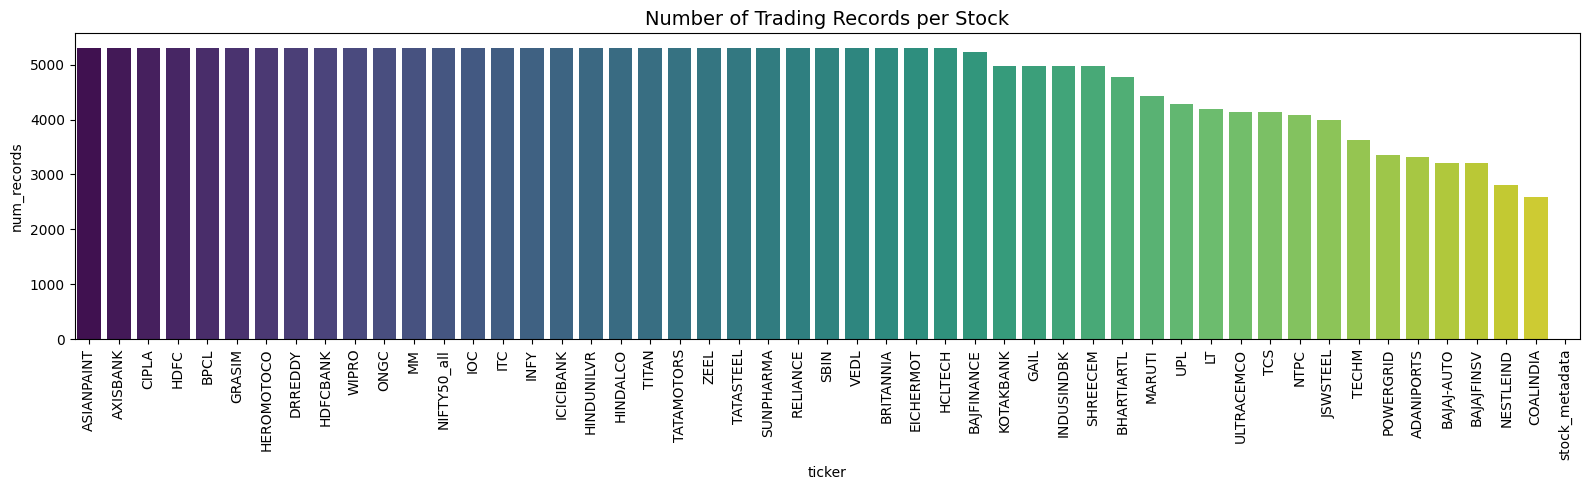

Saved ✅


In [5]:
records_per_stock = df.groupby('ticker').size().sort_values(ascending=False).reset_index()
records_per_stock.columns = ['ticker', 'num_records']

plt.figure(figsize=(16,5))
sns.barplot(data=records_per_stock, x='ticker', y='num_records', palette='viridis')
plt.xticks(rotation=90)
plt.title('Number of Trading Records per Stock', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_FOLDER, 'records_per_stock.png'), dpi=150)
plt.show()
print("Saved ✅")

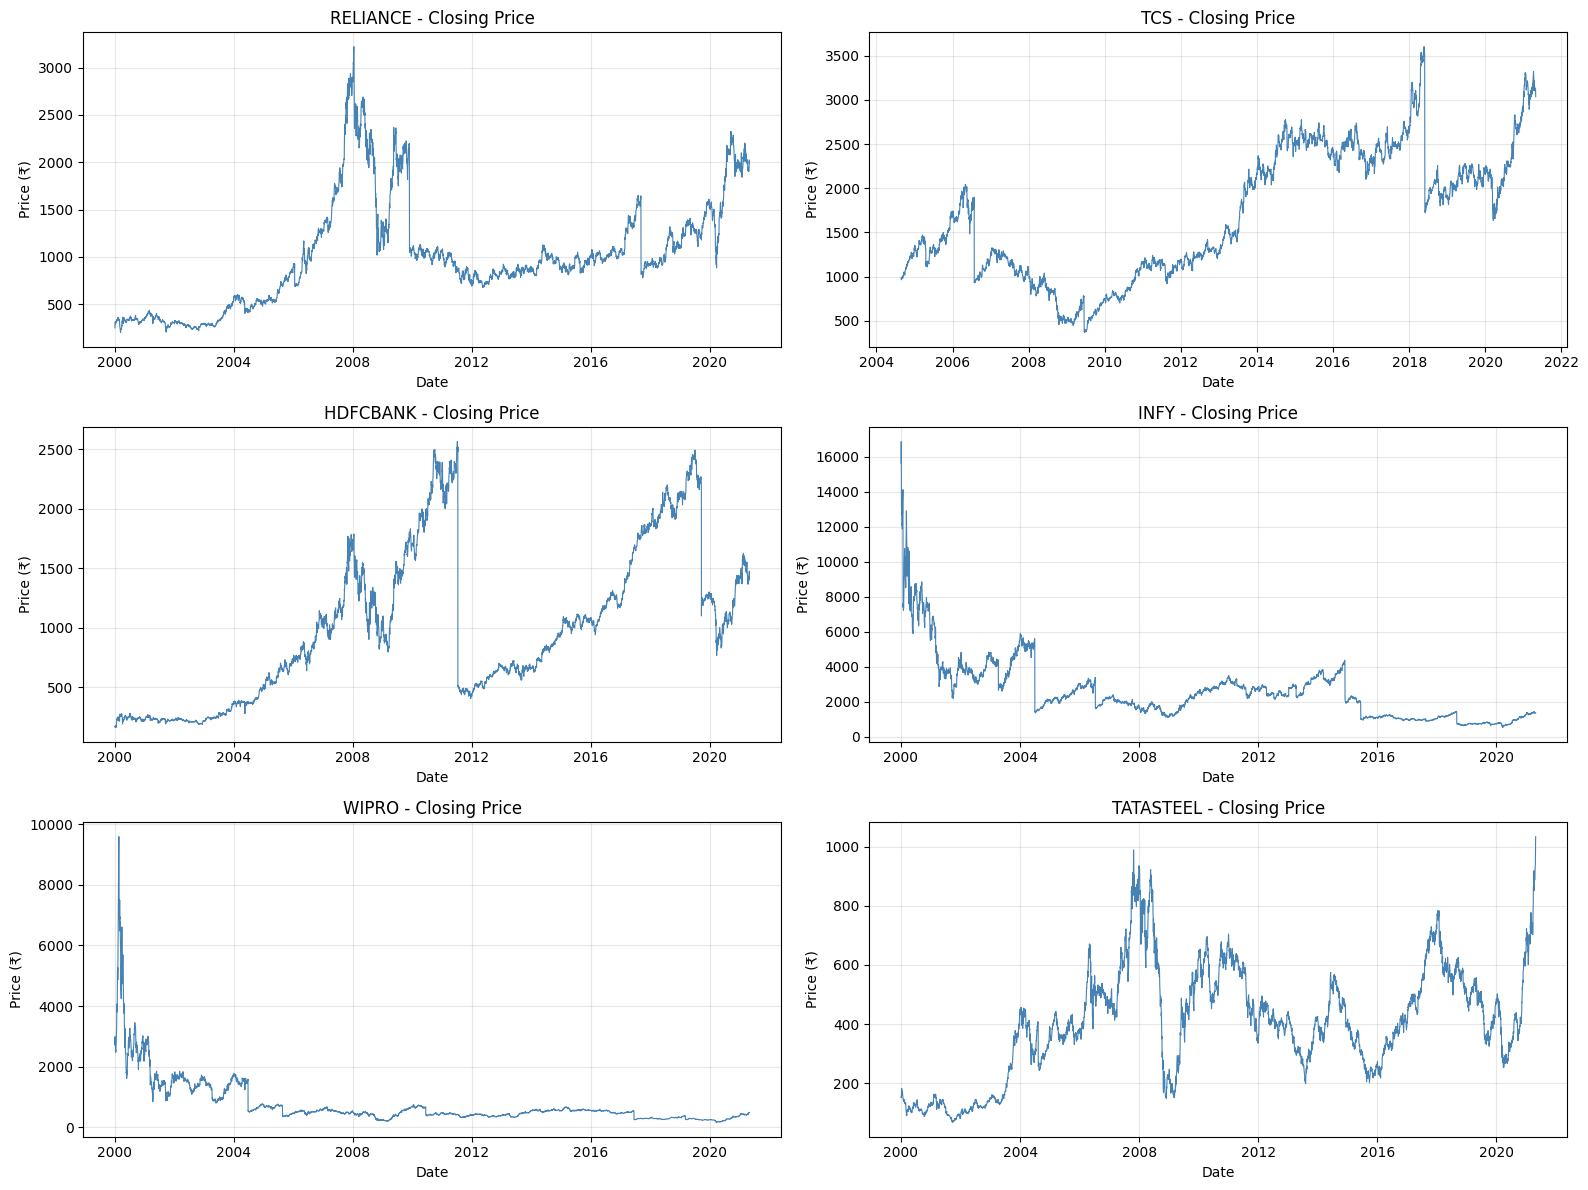

Saved ✅


In [6]:
top6 = ['RELIANCE', 'TCS', 'HDFCBANK', 'INFY', 'WIPRO', 'TATASTEEL']
# Keep only tickers that exist in your data
top6 = [t for t in top6 if t in df['ticker'].unique()]

fig, axes = plt.subplots(3, 2, figsize=(16, 12))
axes = axes.flatten()

for i, ticker in enumerate(top6):
    stock = df[df['ticker'] == ticker]
    axes[i].plot(stock['date'], stock['close'], color='steelblue', linewidth=0.8)
    axes[i].set_title(f'{ticker} - Closing Price', fontsize=12)
    axes[i].set_xlabel('Date')
    axes[i].set_ylabel('Price (₹)')
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_FOLDER, 'top6_closing_prices.png'), dpi=150)
plt.show()
print("Saved ✅")

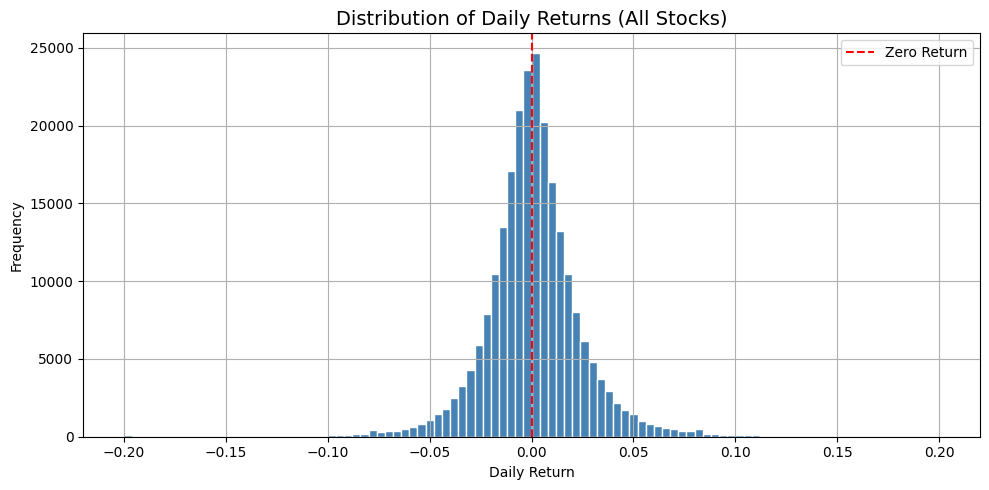

Mean daily return: 0.0007
Std daily return:  0.0272


In [7]:
# Calculate daily returns for all stocks
df['daily_return'] = df.groupby('ticker')['close'].pct_change()

plt.figure(figsize=(10,5))
df['daily_return'].dropna().clip(-0.2, 0.2).hist(bins=100, color='steelblue', edgecolor='white')
plt.title('Distribution of Daily Returns (All Stocks)', fontsize=14)
plt.xlabel('Daily Return')
plt.ylabel('Frequency')
plt.axvline(0, color='red', linestyle='--', linewidth=1.5, label='Zero Return')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_FOLDER, 'daily_returns_dist.png'), dpi=150)
plt.show()

print(f"Mean daily return: {df['daily_return'].mean():.4f}")
print(f"Std daily return:  {df['daily_return'].std():.4f}")

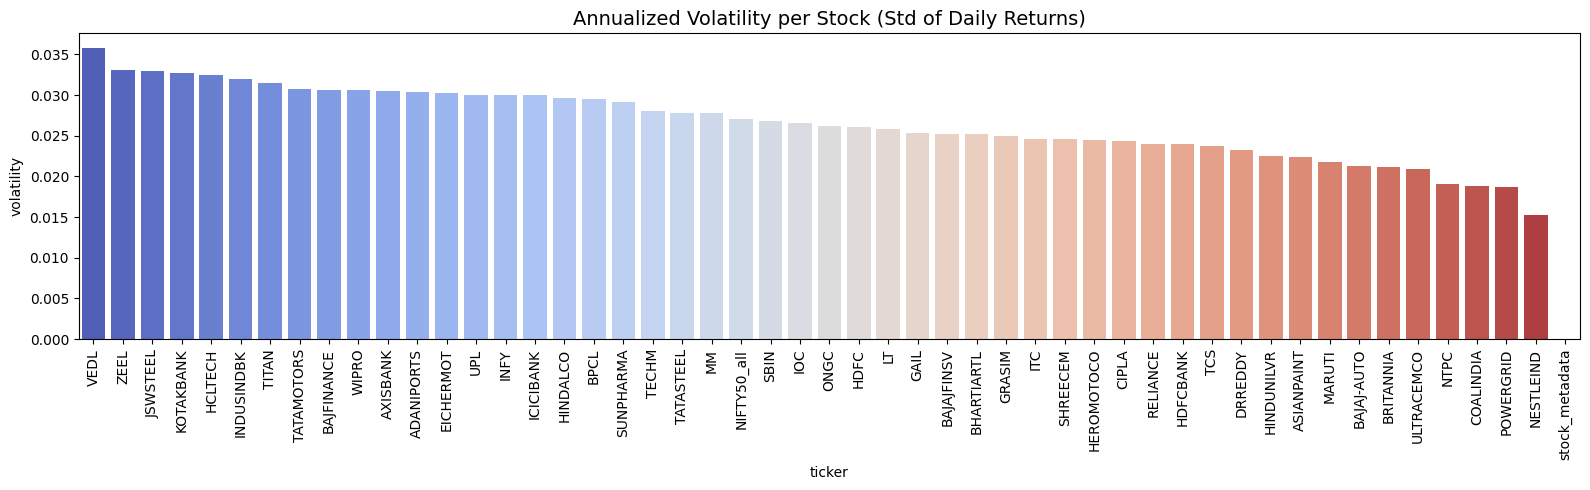

Saved ✅


In [8]:
volatility = df.groupby('ticker')['daily_return'].std().sort_values(ascending=False).reset_index()
volatility.columns = ['ticker', 'volatility']

plt.figure(figsize=(16,5))
sns.barplot(data=volatility, x='ticker', y='volatility', palette='coolwarm')
plt.xticks(rotation=90)
plt.title('Annualized Volatility per Stock (Std of Daily Returns)', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_FOLDER, 'volatility_per_stock.png'), dpi=150)
plt.show()
print("Saved ✅")

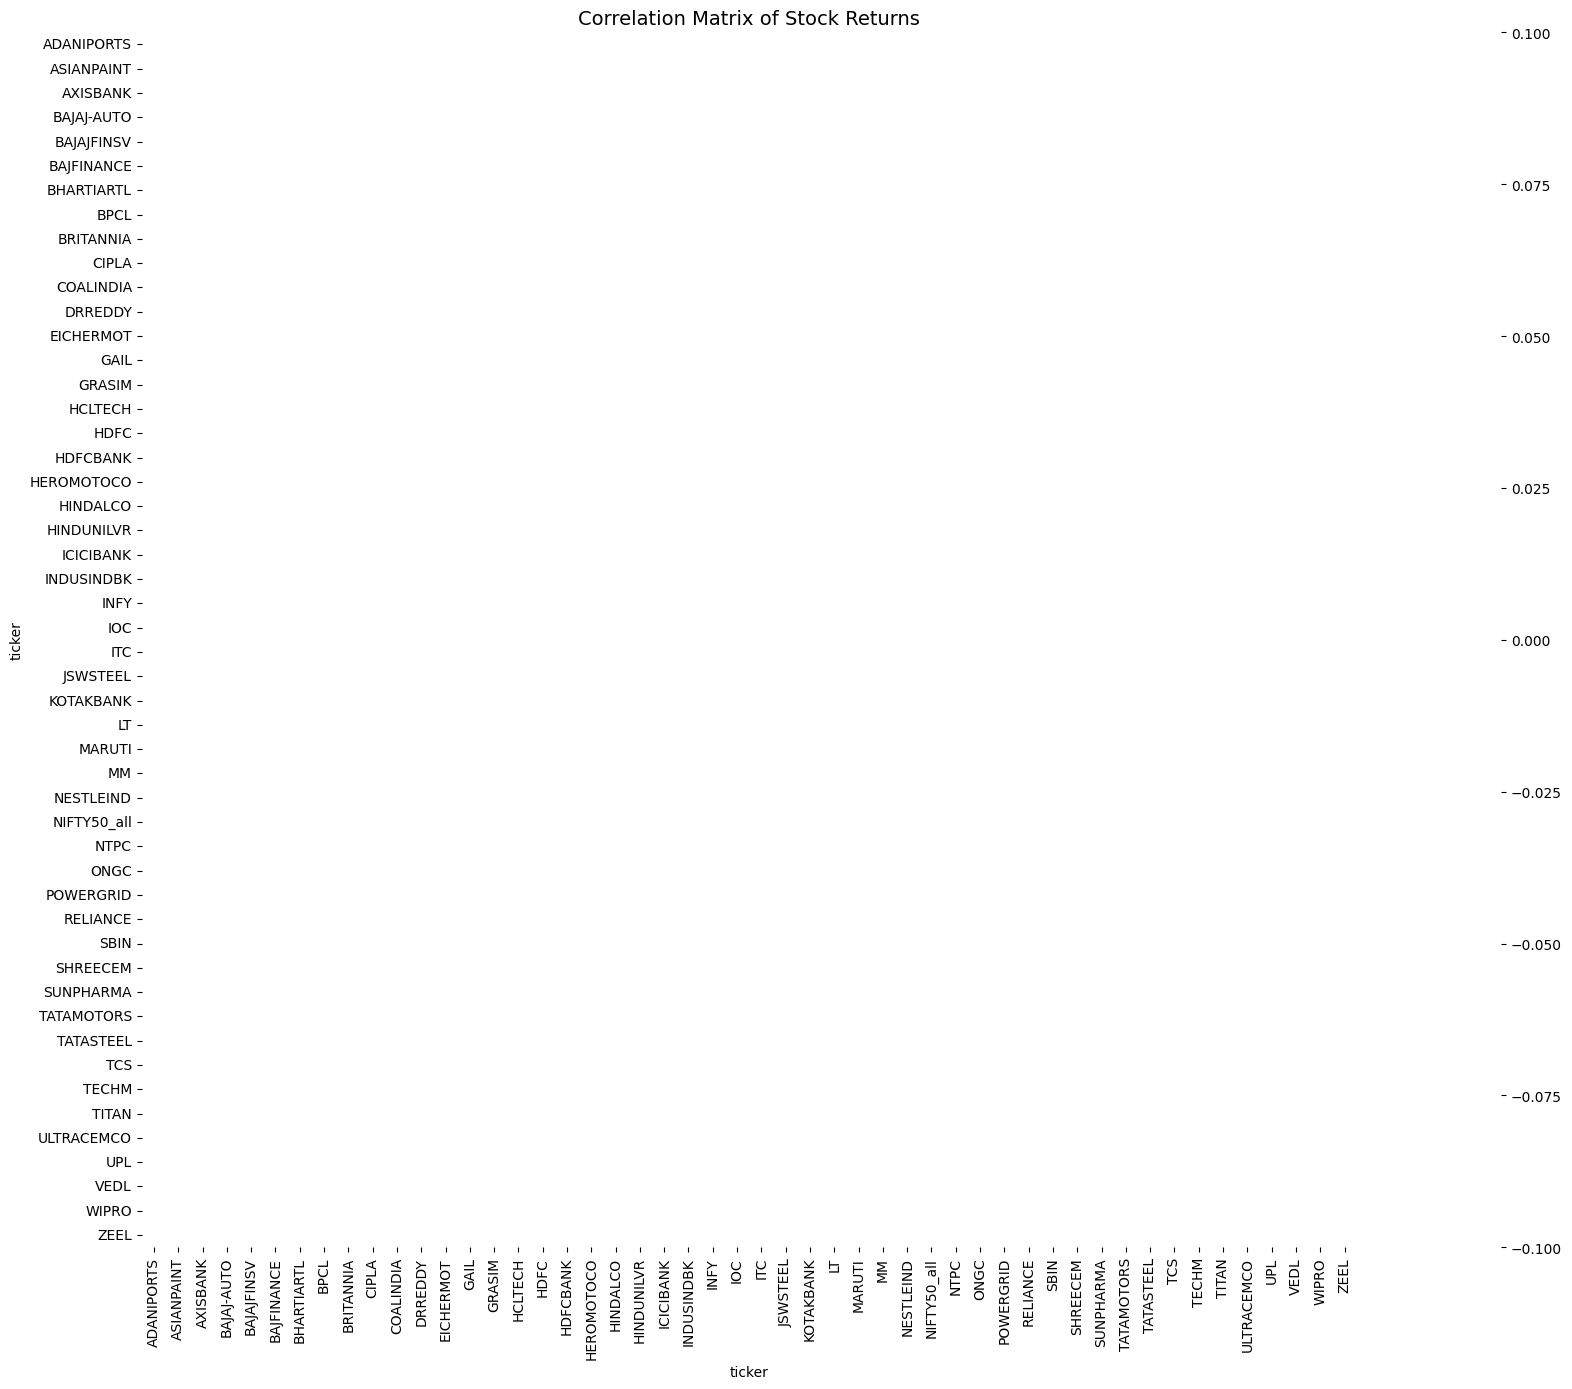

Saved ✅


In [9]:
# Pivot close prices
close_pivot = df.pivot_table(index='date', columns='ticker', values='close')
close_pivot = close_pivot.dropna(thresh=int(0.8 * len(close_pivot)))  # keep columns with 80%+ data

returns_pivot = close_pivot.pct_change().dropna()
corr_matrix = returns_pivot.corr()

plt.figure(figsize=(18,14))
sns.heatmap(corr_matrix, cmap='RdYlGn', center=0, annot=False,
            linewidths=0.3, square=True)
plt.title('Correlation Matrix of Stock Returns', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_FOLDER, 'correlation_heatmap.png'), dpi=150)
plt.show()
print("Saved ✅")

In [10]:
CLEANED_PATH = r"C:\Users\sarin\Downloads\nifty50_project\data\cleaned_data.csv"
df.to_csv(CLEANED_PATH, index=False)
print(f"Cleaned data saved → {CLEANED_PATH}")
print(f"Final shape: {df.shape}")

Cleaned data saved → C:\Users\sarin\Downloads\nifty50_project\data\cleaned_data.csv
Final shape: (240499, 20)
